In [180]:
import os
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from torchvision.transforms import ToPILImage
import torchvision.transforms.v2 as tfs
import matplotlib.pyplot as plt
from PIL import Image


In [181]:
# Тензор из списка

tensor_list = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(f"Создание тензора из списка:\n{tensor_list}")

Создание тензора из списка:
tensor([[1, 2, 3],
        [4, 5, 6]])


In [182]:
# Тензор из np.array

np_array = np.array([[1, 2, 3], [4, 5, 6]])
tensor_numpy = torch.from_numpy(np_array)
print(f"Создание тензора из np.array:\n{tensor_numpy}")

Создание тензора из np.array:
tensor([[1, 2, 3],
        [4, 5, 6]])


In [183]:
# Создание тензоров из встроенных функций

tensor_empty = torch.empty(3, 5, 2) # Пустой тензор размером 3x5x2
tensor_zeros = torch.zeros(3, 3)
tensor_ones = torch.ones(2, 3, 4)
tensor_full = torch.full((2, 2), 7)
tensor_eye = torch.eye(4)
tensor_arange = torch.arange(0, 10, 2)

print(f"\nТензор с нулями:\n{tensor_zeros}")
print(f"\nТензор с единицами:\n{tensor_ones}")
print(f"\nТензор заполненный одним значением:\n{tensor_full}")
print(f"\nТензор в виде единичной матрицы:\n{tensor_eye}")
print(f"\nТензор диапазон:\n{tensor_arange}")


Тензор с нулями:
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

Тензор с единицами:
tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

Тензор заполненный одним значением:
tensor([[7, 7],
        [7, 7]])

Тензор в виде единичной матрицы:
tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.],
        [0., 0., 0., 1.]])

Тензор диапазон:
tensor([0, 2, 4, 6, 8])


In [184]:
# Свойства тензора

tensor = torch.rand(2, 3, 4)
print("Тензор:")
print(tensor)
print("Свойства тензора:")
print(f"Размерность (shape): {tensor.shape}")
print(f"Количество измерений (ndim): {tensor.ndim}")
print(f"Тип данных (dtype): {tensor.dtype}")
print(f"Устройство (device): {tensor.device}")
print(f"Количество элементов: {tensor.numel()}")
print(f"Требует градиента (requires_grad): {tensor.requires_grad}")

Тензор:
tensor([[[0.6753, 0.7575, 0.6478, 0.9163],
         [0.9669, 0.6396, 0.4136, 0.1979],
         [0.4226, 0.0863, 0.7027, 0.9733]],

        [[0.9804, 0.8954, 0.6341, 0.8833],
         [0.1211, 0.7134, 0.1845, 0.7995],
         [0.9988, 0.6983, 0.9833, 0.4590]]])
Свойства тензора:
Размерность (shape): torch.Size([2, 3, 4])
Количество измерений (ndim): 3
Тип данных (dtype): torch.float32
Устройство (device): cpu
Количество элементов: 24
Требует градиента (requires_grad): False


In [185]:
# Преобразования тензора

tensor = torch.FloatTensor(2, 4)

# Заполнить -1:
tensor.fill_(-1)
print("Тензор заполненный -1:")
print(tensor)

# Нормальное распределение:
tensor.normal_(mean=0, std=1)
print("\nТензор заполненный числами с нормальным распределением:")
print(tensor)

# Другое представление:
new_tensor = tensor.view(2, 2, 2)
print("\nТензор в другом представлении:")
print(new_tensor)

# Поменять оси местами:
new_tensor = new_tensor.permute(1, 0, 2)
print("\nТензор с поменяными осями:")
print(new_tensor)


Тензор заполненный -1:
tensor([[-1., -1., -1., -1.],
        [-1., -1., -1., -1.]])

Тензор заполненный числами с нормальным распределением:
tensor([[ 0.2154,  0.7585, -2.0440, -1.6463],
        [-1.2864, -0.4505,  0.9579, -0.6073]])

Тензор в другом представлении:
tensor([[[ 0.2154,  0.7585],
         [-2.0440, -1.6463]],

        [[-1.2864, -0.4505],
         [ 0.9579, -0.6073]]])

Тензор с поменяными осями:
tensor([[[ 0.2154,  0.7585],
         [-1.2864, -0.4505]],

        [[-2.0440, -1.6463],
         [ 0.9579, -0.6073]]])


In [186]:
# Unsqueeze

# Добавить ось
tensor = torch.unsqueeze(tensor, dim=0)
print("Тензор с еще одной осью:")
print(tensor)
print(tensor.shape)

# Добавить ось в конец
tensor = torch.unsqueeze(tensor, dim=-1)
print("\nТензор с еще одной осью:")
print(tensor)
print(tensor.shape)


Тензор с еще одной осью:
tensor([[[ 0.2154,  0.7585, -2.0440, -1.6463],
         [-1.2864, -0.4505,  0.9579, -0.6073]]])
torch.Size([1, 2, 4])

Тензор с еще одной осью:
tensor([[[[ 0.2154],
          [ 0.7585],
          [-2.0440],
          [-1.6463]],

         [[-1.2864],
          [-0.4505],
          [ 0.9579],
          [-0.6073]]]])
torch.Size([1, 2, 4, 1])


In [187]:
# Squeeze

# Убрать одну ось в начале
tensor = torch.squeeze(tensor, dim=0)
print("Тензор без одной оси:")
print(tensor)
print(tensor.shape)

# Убрать все оси размером 1
tensor = torch.squeeze(tensor)
print("Тензор без осей равных 1:")
print(tensor)
print(tensor.shape)

Тензор без одной оси:
tensor([[[ 0.2154],
         [ 0.7585],
         [-2.0440],
         [-1.6463]],

        [[-1.2864],
         [-0.4505],
         [ 0.9579],
         [-0.6073]]])
torch.Size([2, 4, 1])
Тензор без осей равных 1:
tensor([[ 0.2154,  0.7585, -2.0440, -1.6463],
        [-1.2864, -0.4505,  0.9579, -0.6073]])
torch.Size([2, 4])


In [188]:
# Срезы двумерного тензора

tensor_2d = torch.arange(1, 17).reshape(4, 4)

print(f"2D тензор (4x4):\n{tensor_2d}")

print("\nСрезы тензора размера 4x4")
print(f"\nПервая строка: {tensor_2d[0]}")
print(f"\nПервый столбец: {tensor_2d[:, 0]}")
print(f"\nПодматрица 2x2 (строки 1-2, столбцы 2-3):\n{tensor_2d[1:3, 2:4]}")
print(f"\nВсе строки, столбцы 1 и 3:\n{tensor_2d[:, [0, 2]]}")

2D тензор (4x4):
tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12],
        [13, 14, 15, 16]])

Срезы тензора размера 4x4

Первая строка: tensor([1, 2, 3, 4])

Первый столбец: tensor([ 1,  5,  9, 13])

Подматрица 2x2 (строки 1-2, столбцы 2-3):
tensor([[ 7,  8],
        [11, 12]])

Все строки, столбцы 1 и 3:
tensor([[ 1,  3],
        [ 5,  7],
        [ 9, 11],
        [13, 15]])


In [189]:
# Срезы трехмерного тензора

tensor_3d = torch.arange(1, 25).reshape(2, 3, 4)

print(f"\n3D тензор (2x3x4):\n{tensor_3d}")

print("\nСрезы тензора размером 2x3x4:")
print(f"\n(tensor_3d[0]):\n{tensor_3d[0]}")
print(f"\n(tensor_3d[-1]):\n{tensor_3d[-1]}")
print(f"\n0, 1:\n{tensor_3d[0, 1]}")
print(f"\n1, 0-1, 1-3:\n{tensor_3d[1, 0:2, 1:4]}")


3D тензор (2x3x4):
tensor([[[ 1,  2,  3,  4],
         [ 5,  6,  7,  8],
         [ 9, 10, 11, 12]],

        [[13, 14, 15, 16],
         [17, 18, 19, 20],
         [21, 22, 23, 24]]])

Срезы тензора размером 2x3x4:

(tensor_3d[0]):
tensor([[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]])

(tensor_3d[-1]):
tensor([[13, 14, 15, 16],
        [17, 18, 19, 20],
        [21, 22, 23, 24]])

0, 1:
tensor([5, 6, 7, 8])

1, 0-1, 1-3:
tensor([[14, 15, 16],
        [18, 19, 20]])


In [190]:
# Определитель матрицы

tensor_2d = torch.rand(4, 4)

det = torch.linalg.det(tensor_2d)

print(f"Определитель: {det}")

Определитель: 0.009326845407485962


In [191]:
# Автодифференцирование

x = torch.tensor([[2.0, 0.1], [2.0, 0.1]], requires_grad=True)
y = torch.tensor([[3.0, 0.3]], requires_grad=True)

f = x**3 + 2*x*y + y**2
f_scalar = f.sum()          # теперь это скаляр

f_scalar.backward()         # вычисляем ∂(суммы f)/∂x и ∂(суммы f)/∂y

print("x.grad:\n", x.grad)
print("y.grad:\n", y.grad)

x.grad:
 tensor([[18.0000,  0.6300],
        [18.0000,  0.6300]])
y.grad:
 tensor([[20.0000,  1.6000]])


In [192]:
# Скрипт для загрузки датасета

transform = tfs.ToPILImage()

mnist_train = datasets.MNIST(root='./mnist_data', download=True, train=True)
mnist_test = datasets.MNIST(root='./mnist_data', download=True, train=False)

dir_out = 'dataset'
file_format = 'format.json'
train_data = {'dir': "train", 'data': mnist_train}
test_data = {'dir': "test", 'data': mnist_test}

if not os.path.exists(dir_out):
    os.mkdir(dir_out)

    for info in (train_data, test_data):
        os.mkdir(os.path.join(dir_out, info['dir']))

        for i in range(10):
            os.mkdir(os.path.join(dir_out, info['dir'], f"class_{i}"))

for info in (train_data, test_data):
    for i in range(10):
        path = os.path.join(dir_out, info['dir'], f"class_{i}")
        cls = info['data'].data[info['data'].targets == i]

        for n, x in enumerate(cls):
            x = transform(x)
            x.save(os.path.join(path, f"img_{n}.png"), "png")

targets = dict()
for i in range(10):
    targets[f'class_{i}'] = i

fp = open(os.path.join(dir_out, file_format), "w")
json.dump(targets, fp)
fp.close()

In [193]:
# Свой класс датасета

class CustomDataset(Dataset):
    def __init__(self, path, train=True, transform=None):
        self.path = os.path.join(path, "train" if train else "test")
        self.transform = transform

        # Раскладываем датасет в стандартную организацию файлов
        with open(os.path.join(path, "format.json"), "r") as fp:
            self.format = json.load(fp)
 
        self.length = 0
        self.files = []
        self.targets = torch.eye(10)
 
        for _dir, _target in self.format.items():
            path = os.path.join(self.path, _dir)
            list_files = os.listdir(path)
            self.length += len(list_files)
            self.files.extend(map(lambda _x: (os.path.join(path, _x), _target), list_files))
    
    # Для получения элемента с индексом item
    def __getitem__(self, item):
        path_file, target = self.files[item]
        t = self.targets[target]
        img = Image.open(path_file)
        # Нормировка [0, 1]
        if self.transform:
            img = self.transform(img).ravel().float()
 
        return img, t
    
    # Размер датасета
    def __len__(self):
        return self.length

Размер датасета = 60000


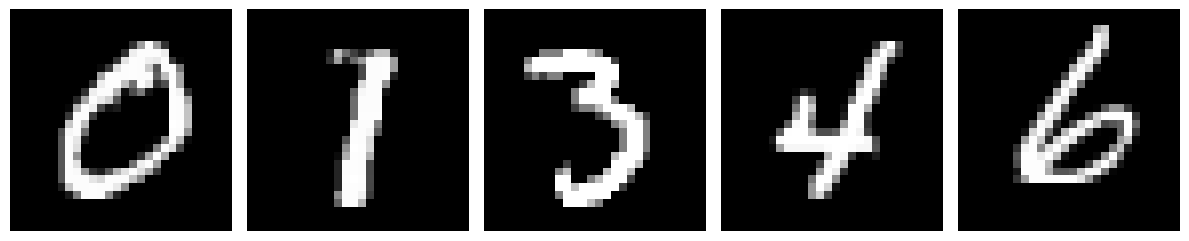

In [199]:
dataset = CustomDataset('dataset', transform=tfs.ToImage())

print(f"Размер датасета = {dataset.length}")

fig, axes = plt.subplots(1, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img_1d, target = dataset[i * 10000]
    
    img_2d = img_1d.view(28, 28)
    
    ax.imshow(img_2d, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()

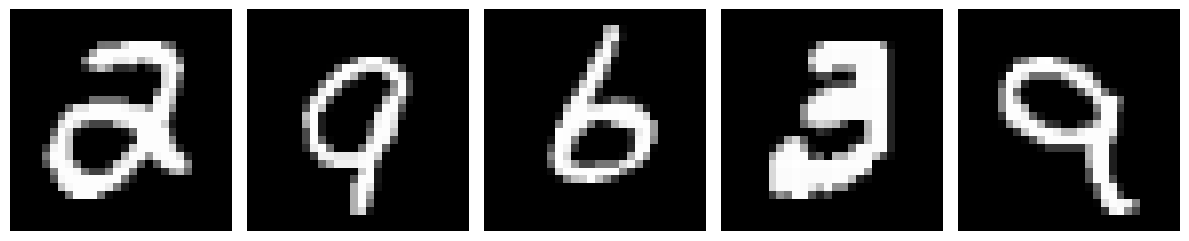

In [202]:
# DataLoader

data = DataLoader(dataset, batch_size=32, shuffle=True)

# Получаем один батч
images_batch, labels_batch = next(iter(data))

fig, axes = plt.subplots(1, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img_1d = images_batch[i]
    img_2d = img_1d.view(28, 28)
    
    ax.imshow(img_2d, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.show()